# Clustering

## Import Library

In [1]:
import joblib
import json
import pandas as pd
import numpy as np
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

## Load Datasets

In [2]:
df = pd.read_csv('data/dataset/cleaned.csv')
df.head()

,cpu_usage,memory_usage,temperature,battery_level,battery_drain,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness
0,1.147751,-0.022174,-0.776643,0.345863,0.330735,0,-0.907048,-0.634519,1,-0.987847
1,1.972228,-0.022174,-0.776643,0.345863,-0.402312,0,3.482663,2.587398,1,-0.987847
2,-0.243555,-0.022174,-0.776643,0.345863,0.396874,0,-0.421329,-0.630424,1,-0.987847
3,-0.707324,-0.022174,-0.776643,0.345863,0.766153,0,0.103522,-0.625933,1,-0.987847
4,-0.707324,0.439932,-0.776643,0.345863,0.793711,0,-0.012596,-0.607760,1,-0.987847


In [3]:
df.describe()

,cpu_usage,memory_usage,temperature,battery_level,battery_drain,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness
count,1.042000e+03,1.042000e+03,1.042000e+03,1042.000000,1.042000e+03,1042.0,1.042000e+03,1042.000000,1042.0,1.042000e+03
mean,-2.182089e-16,7.091789e-16,2.454850e-15,0.000000,-2.182089e-16,0.0,6.478077e-17,0.000000,1.0,1.091045e-16
std,1.000480e+00,1.000480e+00,1.000480e+00,1.000480,1.000480e+00,0.0,1.000480e+00,1.000480,0.0,1.000480e+00
min,-1.583331e+00,-3.256917e+00,-1.565334e+00,-2.078671,-3.411660e+00,0.0,-9.070483e-01,-0.634519,1.0,-9.878469e-01
25%,-9.649730e-01,-7.153332e-01,-1.105264e+00,-0.693223,-8.487535e-01,0.0,-7.616075e-01,-0.632055,1.0,-9.878469e-01
50%,-2.177902e-01,-2.217400e-02,2.092200e-01,0.172682,3.197114e-01,0.0,-3.286220e-01,-0.610762,1.0,8.943684e-01
75%,8.901014e-01,9.020382e-01,6.692895e-01,0.865406,8.488276e-01,0.0,3.807739e-01,0.806057,1.0,8.943684e-01
max,2.332937e+00,1.595197e+00,2.641016e+00,1.558130,1.973199e+00,0.0,4.277705e+00,3.246710,1.0,3.011861e+00


In [4]:
df_dropped = df.drop(columns=['battery_charging', 'screen_on'])

## Clustering

### K-Means

#### Training

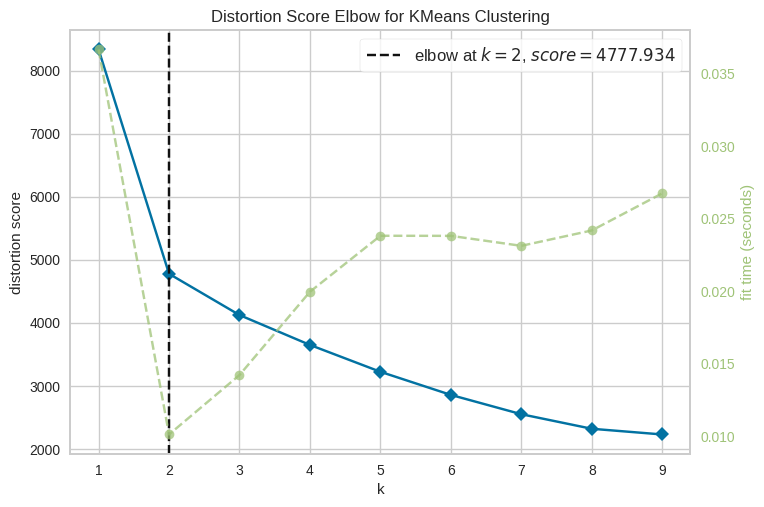

2


In [5]:
X = df_dropped.select_dtypes(include=['float64','int64']).to_numpy()
model = KMeans(random_state=42, n_init=10)

visualizer = KElbowVisualizer(
    model,
    k=(1,10),
    force_model=True
)

visualizer.fit(X)
visualizer.show()
best_k = visualizer.elbow_value_
print(best_k)

In [6]:
model_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = model_kmeans.fit_predict(X)
df_kmeans = df_dropped.copy()

df_kmeans['Target'] = cluster_labels
df_kmeans.head()

,cpu_usage,memory_usage,temperature,battery_level,battery_drain,upload_speed_kbps,download_speed_kbps,brightness,Target
0,1.147751,-0.022174,-0.776643,0.345863,0.330735,-0.907048,-0.634519,-0.987847,1
1,1.972228,-0.022174,-0.776643,0.345863,-0.402312,3.482663,2.587398,-0.987847,1
2,-0.243555,-0.022174,-0.776643,0.345863,0.396874,-0.421329,-0.630424,-0.987847,1
3,-0.707324,-0.022174,-0.776643,0.345863,0.766153,0.103522,-0.625933,-0.987847,1
4,-0.707324,0.439932,-0.776643,0.345863,0.793711,-0.012596,-0.607760,-0.987847,1


In [7]:
df_kmeans.to_csv('data/kmeans.csv', index=False)

In [8]:
joblib.dump(model_kmeans, 'model/kmeans_model.pkl')

['model/kmeans_model.pkl']

#### Evaluation

In [9]:
silhouette_score(X, df_kmeans['Target'])

0.40504972133931955

In [10]:
davies_bouldin_score(X, df_kmeans['Target'])

1.0542983578684675

In [11]:
calinski_harabasz_score(X, df_kmeans['Target'])

774.4745807765046

### DBScan

#### Training

In [12]:
df_dbscan = df_dropped.copy()
X_dbscan = df.select_dtypes(include=['float64','int64']).to_numpy()
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5,
)

labels = dbscan.fit_predict(X)
df_dbscan["label"] = labels
df_dbscan.head()

,cpu_usage,memory_usage,temperature,battery_level,battery_drain,upload_speed_kbps,download_speed_kbps,brightness,label
0,1.147751,-0.022174,-0.776643,0.345863,0.330735,-0.907048,-0.634519,-0.987847,-1
1,1.972228,-0.022174,-0.776643,0.345863,-0.402312,3.482663,2.587398,-0.987847,-1
2,-0.243555,-0.022174,-0.776643,0.345863,0.396874,-0.421329,-0.630424,-0.987847,-1
3,-0.707324,-0.022174,-0.776643,0.345863,0.766153,0.103522,-0.625933,-0.987847,-1
4,-0.707324,0.439932,-0.776643,0.345863,0.793711,-0.012596,-0.607760,-0.987847,-1


In [13]:
df_dbscan.to_csv("data/dbscan.csv", index=False)

In [14]:
joblib.dump(dbscan, 'model/dbscan_model.pkl')

['model/dbscan_model.pkl']

In [15]:
silhouette_score(X_dbscan, df_dbscan['label'])

-0.16607629318718123

In [16]:
davies_bouldin_score(X_dbscan, df_dbscan['label'])

1.1891700267678713

In [17]:
calinski_harabasz_score(X_dbscan, df_dbscan['label'])

32.296599903161855

## Analysis (K-Means)

In [18]:
cluster_analysis = df_kmeans.groupby('Target').agg(['mean', 'min', 'max'])
cluster_analysis

cpu_usage                     memory_usage                      \
            mean       min       max         mean       min       max   
Target                                                                  
0       0.841744 -1.222622  2.332937     0.898114 -2.332705  1.595197   
1      -0.694328 -1.583331  2.332937    -0.740826 -3.256917  0.902038   

       temperature                     battery_level  ... battery_drain  \
              mean       min       max          mean  ...           max   
Target                                                ...                 
0         0.641939 -1.433885  1.786601     -0.846548  ...      1.488176   
1        -0.529516 -1.565334  2.641016      0.698291  ...      1.973199   

       upload_speed_kbps                     download_speed_kbps            \
                    mean       min       max                mean       min   
Target                                                                       
0              -0.132804 -0.907048  4.193206           -0.064985 -0.634519   
1               0.109546 -0.907048  4.277705            0.053604 -0.634519   

                 brightness                      
             max       mean       min       max  
Target                                           
0       3.246710   0.822936 -0.987847  3.011861  
1       3.132694  -0.678814 -0.987847  3.011861  

[2 rows x 24 columns]

### Inverse

In [19]:
with open("data/scaler.json") as f:
    scaler_params = json.load(f)

mean = np.array(scaler_params['mean'])
scale = np.array(scaler_params['scale'])

In [20]:
X_scaled = df_dropped.values
X_original = X_scaled * scale + mean

df_original = pd.DataFrame(
    X_original,
    columns=df_dropped.columns
)
df_original.head()

,cpu_usage,memory_usage,temperature,battery_level,battery_drain,upload_speed_kbps,download_speed_kbps,brightness
0,77.0,75.0,33.2,47.0,-308.0,0.000000,0.000000,23.0
1,93.0,75.0,33.2,47.0,-441.0,7.612117,111.012924,23.0
2,50.0,75.0,33.2,47.0,-296.0,0.842276,0.141110,23.0
3,41.0,75.0,33.2,47.0,-229.0,1.752412,0.295840,23.0
4,41.0,77.0,33.2,47.0,-224.0,1.551054,0.921999,23.0


In [21]:
df_original['Target'] = df_kmeans['Target']
df_original.head()

,cpu_usage,memory_usage,temperature,battery_level,battery_drain,upload_speed_kbps,download_speed_kbps,brightness,Target
0,77.0,75.0,33.2,47.0,-308.0,0.000000,0.000000,23.0,1
1,93.0,75.0,33.2,47.0,-441.0,7.612117,111.012924,23.0,1
2,50.0,75.0,33.2,47.0,-296.0,0.842276,0.141110,23.0,1
3,41.0,75.0,33.2,47.0,-229.0,1.752412,0.295840,23.0,1
4,41.0,77.0,33.2,47.0,-224.0,1.551054,0.921999,23.0,1


In [22]:
df_original.to_csv("data/original_kmeans.csv", index=False)

In [23]:
cluster_analysis = df_original.groupby('Target').agg(['mean', 'min', 'max'])
df_analysis = cluster_analysis.reset_index()
df_analysis.head()

Target  cpu_usage              memory_usage             temperature        \
               mean   min    max         mean   min   max        mean   min   
0      0  71.061571  31.0  100.0    78.983015  65.0  82.0   35.358386  32.2   
1      1  41.252189  24.0  100.0    71.889667  61.0  79.0   33.576007  32.0   

         ... battery_drain upload_speed_kbps                 \
    max  ...           max              mean  min       max   
0  37.1  ...         -98.0          1.342602  0.0  8.844257   
1  38.4  ...         -10.0          1.762857  0.0  8.990784   

  download_speed_kbps                 brightness              
                 mean  min        max       mean   min   max  
0           19.623632  0.0  133.72989  30.696391  23.0  40.0  
1           23.709654  0.0  129.80138  24.313485  23.0  40.0  

[2 rows x 25 columns]

In [24]:
df_analysis.to_csv("data/cluster_analysis.csv", index=False)